In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.extmath import randomized_svd

from src.utils.grid import build_xyz
from src.decomposition.tucker import perform_tucker, reconstruct, perform_tucker_rpca
from src.decomposition.rpca import randomized_rpca
from src.potential.poisson_solver import poisson_solve
from src.potential.charge_potential import v_analytic_gaussian

In [2]:
N = 151
L = 20
alpha = 1.0

dx = L / N
eps = dx / 2
xyz = build_xyz(N, L)
R = np.sqrt(xyz[0]**2 + xyz[1]**2 + xyz[2]**2)

rho_grid = np.exp(-alpha * R**2)

print(f"rho max/min = {rho_grid.max():.4f} / {rho_grid.min():.4f}")

rho max/min = 1.0000 / 0.0000


## 指数関数による展開近似

In [ ]:
from src.approximation.exp_sum import (
    ExponentialSum,
    LogUniformGrid,
    VarproOptimizer,
    BenchmarkRunner,
)
from src.utils.cache import load_or_compute

fit_grid = LogUniformGrid(r_min=1e-2, r_max=2*np.sqrt(3)*L, n_points=2000)
eval_grid = LogUniformGrid(r_min=1e-2, r_max=2*np.sqrt(3)*L, n_points=2000)

ranks = [2, 4, 6, 8, 10, 15, 20, 30]
nonneg = True
max_iter = 200000

optimizer = VarproOptimizer(
    fit_grid=fit_grid,
    eval_grid=eval_grid,
    nonneg=nonneg,
    max_iter=max_iter,
)

runner = BenchmarkRunner(optimizer=optimizer, ranks=ranks)

fits_cache_params = {
    "fit_grid": (fit_grid.r_min, fit_grid.r_max, fit_grid.n_points),
    "eval_grid": (eval_grid.r_min, eval_grid.r_max, eval_grid.n_points),
    "nonneg": nonneg,
    "max_iter": max_iter,
    "ranks": tuple(ranks),
}

fits = load_or_compute(
    namespace="exp_sum_fits",
    params=fits_cache_params,
    compute=runner.run,
)

# 表示 (キャッシュヒット時にも結果が見えるように)
print(f"{'R':>4}  {'L2 rel err':>14}  {'L\u221e rel err':>14}")
print("-" * 38)
for r in sorted(fits):
    print(f"{r:>4}  {fits[r].l2_error:>14.3e}  {fits[r].linf_error:>14.3e}")


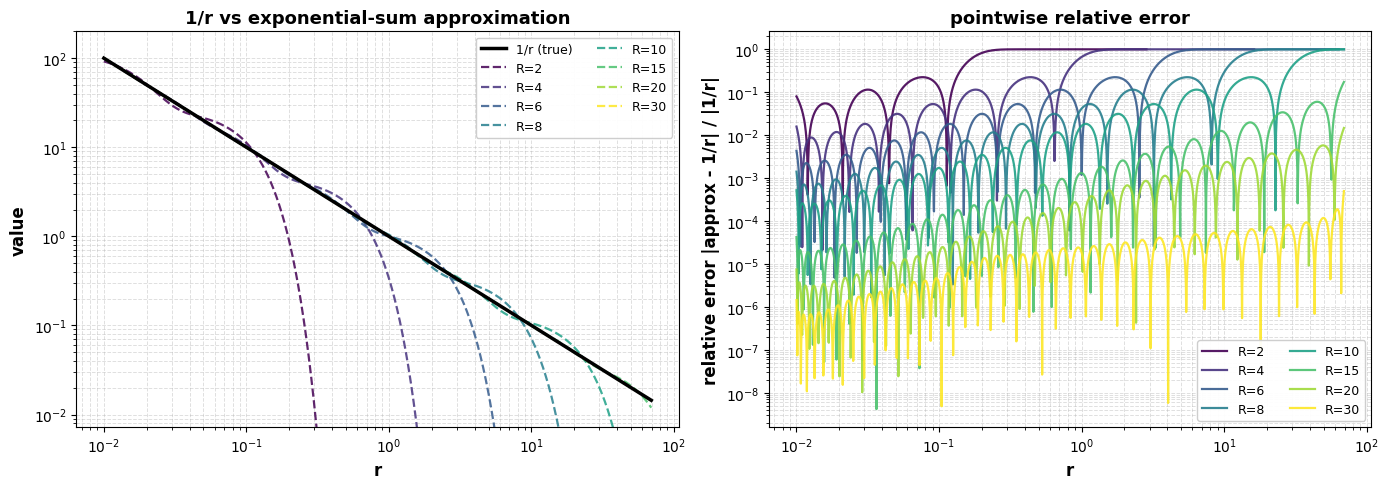

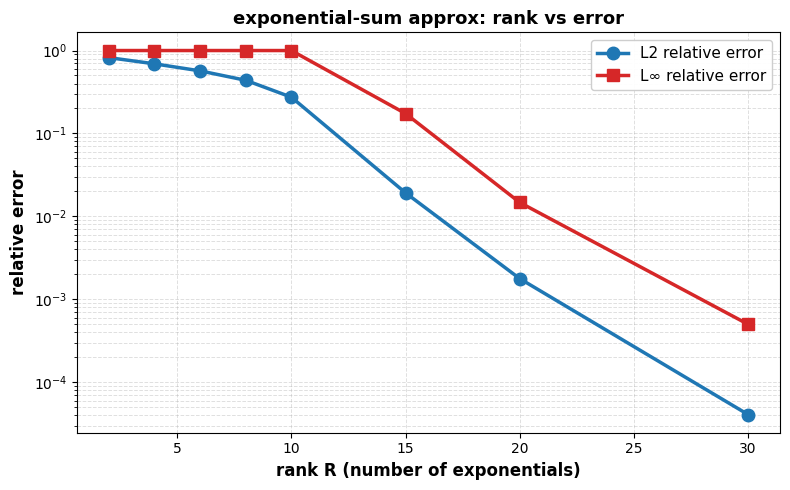

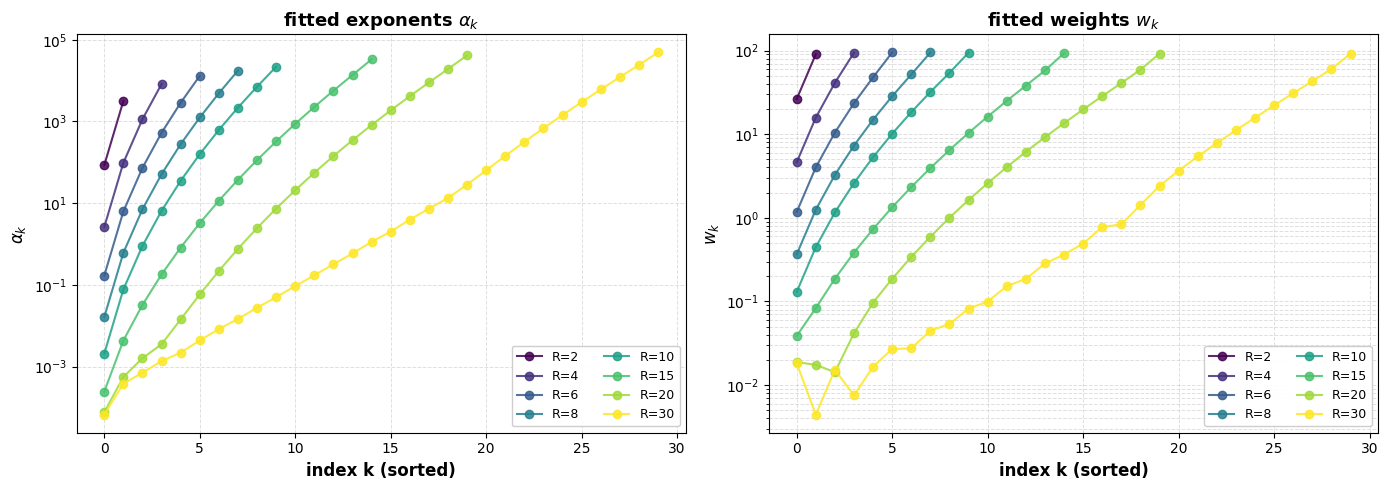

In [4]:
_UNDERFLOW_THRESHOLD = 1e-300


def _masked_loglog(ax, x, y, **kwargs):
    """y > threshold の点のみ loglog プロット（アンダーフロー除外）。"""
    valid = y > _UNDERFLOW_THRESHOLD
    if valid.any():
        ax.loglog(x[valid], y[valid], **kwargs)


def _make_colormap(n: int):
    cmap = plt.get_cmap("viridis")
    return [cmap(i / max(n - 1, 1)) for i in range(n)]


# ---------------------------------------------------------------------------
# 図1 + 図2: 近似カーブ と 点ごとの相対誤差
# ---------------------------------------------------------------------------

def plot_approximation(fits: dict, eval_grid: LogUniformGrid) -> None:
    r_eval = eval_grid.points
    f_true = 1.0 / r_eval
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.loglog(r_eval, f_true, "k-", lw=2.5, label="1/r (true)", zorder=10)

    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        _masked_loglog(ax, r_eval, approx, lw=1.6, ls="--",
                       color=color, alpha=0.85, label=f"R={r}")

    ax.set_ylim(f_true.min() * 0.5, f_true.max() * 2.0)
    ax.set_xlabel("r", fontsize=12, fontweight="bold")
    ax.set_ylabel("value", fontsize=12, fontweight="bold")
    ax.set_title("1/r vs exponential-sum approximation", fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    ax2 = axes[1]
    for color, r in zip(colors, ranks):
        approx = fits[r].evaluate(r_eval)
        valid = approx > _UNDERFLOW_THRESHOLD
        if valid.any():
            rel_err = np.abs((approx[valid] - f_true[valid]) / f_true[valid])
            ax2.loglog(r_eval[valid], rel_err, "-", lw=1.6,
                       color=color, alpha=0.9, label=f"R={r}")

    ax2.set_xlabel("r", fontsize=12, fontweight="bold")
    ax2.set_ylabel("relative error |approx - 1/r| / |1/r|",
                   fontsize=12, fontweight="bold")
    ax2.set_title("pointwise relative error", fontsize=13, fontweight="bold")
    ax2.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax2.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図3: ランク vs L2 / L∞ 誤差
# ---------------------------------------------------------------------------

def plot_rank_vs_error(fits: dict) -> None:
    ranks = sorted(fits.keys())
    l2_errs = [fits[r].l2_error for r in ranks]
    linf_errs = [fits[r].linf_error for r in ranks]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(ranks, l2_errs, "o-", markersize=9, lw=2.5,
                label="L2 relative error", color="C0")
    ax.semilogy(ranks, linf_errs, "s-", markersize=9, lw=2.5,
                label="L∞ relative error", color="C3")
    ax.set_xlabel("rank R (number of exponentials)", fontsize=12, fontweight="bold")
    ax.set_ylabel("relative error", fontsize=12, fontweight="bold")
    ax.set_title("exponential-sum approx: rank vs error",
                 fontsize=13, fontweight="bold")
    ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
    ax.legend(fontsize=11, loc="best", framealpha=0.95)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 図4: α_k と w_k の分布
# ---------------------------------------------------------------------------

def plot_param_distribution(fits: dict) -> None:
    ranks = sorted(fits.keys())
    colors = _make_colormap(len(ranks))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for color, r in zip(colors, ranks):
        idx = np.arange(r)
        axes[0].semilogy(idx, fits[r].alphas, "o-", color=color,
                         alpha=0.85, label=f"R={r}", markersize=6)
        axes[1].semilogy(idx, np.maximum(fits[r].weights, 1e-16), "o-",
                         color=color, alpha=0.85, label=f"R={r}", markersize=6)

    for ax, ylabel, title in zip(
        axes,
        [r"$\alpha_k$", r"$w_k$"],
        [r"fitted exponents $\alpha_k$", r"fitted weights $w_k$"],
    ):
        ax.set_xlabel("index k (sorted)", fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.grid(True, which="both", alpha=0.4, linestyle="--", linewidth=0.7)
        ax.legend(fontsize=9, loc="best", ncol=2, framealpha=0.95)

    plt.tight_layout()
    plt.show()


plot_approximation(fits, eval_grid)
plot_rank_vs_error(fits)
plot_param_distribution(fits)

In [5]:
V_analytic = v_analytic_gaussian(R, alpha)

In [6]:
"""
coulomb_kernel.py
=================
指数和近似を用いた Hartree ポテンシャルの高速計算モジュール。

背景
----
Hartree ポテンシャルは次の畳み込み積分で定義される::

    V_H(r1) = ∫ ρ(r2) / |r1 - r2| dr2

3D グリッド（各方向 N 点）上で愚直に離散化すると O(N^6) の計算が必要となる。

アイデア
--------
Coulomb カーネル 1/r を Gaussian の重ね合わせで近似する::

    1/r ≈ Σ_k w_k * exp(-α_k * r²)

これにより積分は次のように変換される::

    V_H(r1) ≈ Σ_k w_k * ∫ ρ(r2) exp(-α_k |r1-r2|²) dr2

Gaussian カーネルは各座標方向に分離できる::

    exp(-α|r1-r2|²) = exp(-α(x1-x2)²) · exp(-α(y1-y2)²) · exp(-α(z1-z2)²)

したがって 3D の畳み込みが 1D カーネルの逐次適用（mode-n product）に帰着し、
計算量が O(R·N^4) まで削減される（R: 指数和の項数）。
"""

from __future__ import annotations
# ---------------------------------------------------------------------------
# 1D カーネル行列の構築
# ---------------------------------------------------------------------------

def build_gaussian_kernel_1d(alpha: float, x: np.ndarray) -> np.ndarray:
    """
    1D Gaussian カーネル行列を構築する。

    グリッド点のペア (x_i, x_j) に対して次の行列を返す::

        K[i, j] = exp(-alpha * (x_i - x_j)²)

    これは「グリッド点 j にある電荷密度が点 i のポテンシャルに与える寄与」を
    表す重み行列であり、対称行列 (K = K^T) になる。

    Parameters
    ----------
    alpha : float
        Gaussian の幅パラメータ。大きいほど遠距離の寄与が減衰する。
    x : np.ndarray, shape (N,)
        1D グリッド点の座標配列。

    Returns
    -------
    K : np.ndarray, shape (N, N)
        Gaussian カーネル行列。
    """
    diff = x[:, None] - x[None, :]  # ブロードキャストで差分行列を構築: diff[i,j] = x_i - x_j
    return np.exp(-alpha * diff ** 2)


# ---------------------------------------------------------------------------
# 3D テンソルへの mode-n product
# ---------------------------------------------------------------------------

def apply_1d_kernel_along_axis(K: np.ndarray, rho: np.ndarray, axis: int) -> np.ndarray:
    """
    3D 密度テンソル rho の指定軸に沿って行列 K を作用させる（mode-n product）。

    指定した軸方向の添字について行列-ベクトル積を取り、その軸の情報を K で変換する::

        axis=0: result[i, j, k] = Σ_{i'} K[i, i'] * ρ[i', j, k]
        axis=1: result[i, j, k] = Σ_{j'} K[j, j'] * ρ[i, j', k]
        axis=2: result[i, j, k] = Σ_{k'} K[k, k'] * ρ[i, j, k']

    実装の注意
    ----------
    ``np.tensordot(K, rho, axes=([1], [axis]))`` は K の軸1 と rho の指定軸を縮約する。
    結果の軸順は ``(K の軸0, rho の残り軸...)`` となるため、
    ``np.moveaxis`` で K 側の軸を元の位置に戻す必要がある。

    Parameters
    ----------
    K : np.ndarray, shape (N, N)
        適用する 1D カーネル行列。
    rho : np.ndarray, shape (N, N, N)
        電荷密度テンソル。
    axis : int
        K を作用させる軸（0, 1, 2 のいずれか）。

    Returns
    -------
    result : np.ndarray, shape (N, N, N)
        指定軸方向に K を作用させた結果テンソル。
    """
    # tensordot 後、縮約した K 側の軸（軸0に来る）を元の axis の位置に戻す
    return np.moveaxis(np.tensordot(K, rho, axes=([1], [axis])), 0, axis)


def apply_separable_kernel_3d(alpha: float, x: np.ndarray, rho: np.ndarray) -> np.ndarray:
    """
    3D Gaussian カーネルを分離性を利用して密度テンソル rho に作用させる。

    計算したい積分::

        result[i,j,k] = Σ_{i'j'k'} exp(-α[(x_i-x_{i'})² + (y_j-y_{j'})² + (z_k-z_{k'})²])
                        * ρ[i', j', k']

    Gaussian の指数部が各軸の和になっているため積に分解でき::

        exp(-α|r1-r2|²) = exp(-α(x1-x2)²) · exp(-α(y1-y2)²) · exp(-α(z1-z2)²)

    6次元の総和 Σ_{i'j'k'} を「1次元の総和 3 回」に分解できる::

        result[i,j,k] = Σ_{i'} K[i,i'] * Σ_{j'} K[j,j'] * Σ_{k'} K[k,k'] * ρ[i',j',k']

    Parameters
    ----------
    alpha : float
        Gaussian の幅パラメータ。
    x : np.ndarray, shape (N,)
        1D グリッド点の座標配列（x, y, z 方向に同一グリッドを想定）。
    rho : np.ndarray, shape (N, N, N)
        電荷密度テンソル。

    Returns
    -------
    result : np.ndarray, shape (N, N, N)
        exp(-α|r1-r2|²) カーネルで rho を畳み込んだ結果。
        Hartree ポテンシャルを得るには Σ_k w_k * apply_separable_kernel_3d(α_k, ...) の後
        dx^3 を乗じる必要がある。
    """
    K = build_gaussian_kernel_1d(alpha, x)

    result = apply_1d_kernel_along_axis(K, rho, axis=0)  # x 方向の畳み込み
    result = apply_1d_kernel_along_axis(K, result, axis=1)  # y 方向の畳み込み
    result = apply_1d_kernel_along_axis(K, result, axis=2)  # z 方向の畳み込み

    return result

対角成分の補正 ($1/r$ に対する近傍積分)

クーロンカーネル $1/r$ を離散化する際、同一セル内（$r=0$）の寄与を正しく評価する必要があります。指数和近似では中心での値が有限値 $\sum w_k$ となり、厳密な特異性を表現できません。
そこで、一辺 $dx$ の立方体領域の内部で $1/r$ を積分した解析値を用いて誤差を補正します。

単位立方体 $[-0.5, 0.5]^3$ における $1/r$ の体積積分は約 `2.38` となることが知られています。
これを用いて、対角成分の真の寄与は変数のスケール変換から以下のように求まります。

$$
K_{\text{diag}} = \frac{1}{dx^3} \iiint_{[-dx/2, dx/2]^3} \frac{1}{r} d^3r \approx \frac{2.38}{dx}
$$

実際の計算では、指数和近似がもつ対角成分 $\sum w_k$ と真の寄与 $2.38/dx$ の差分を加えることで近傍の誤差を補正します。

E_analytic = 1.236971e+01
   R |     1/r L2 | V err (no) | V err (corr) | E err (no) | E err (corr) |     Σw_k
------------------------------------------------------------------------------------------
   2 |  8.216e-01 |  9.978e-01 |    9.991e-01 |  9.684e-01 |    9.867e-01 |  116.845
   4 |  6.915e-01 |  9.723e-01 |    9.734e-01 |  5.955e-01 |    6.210e-01 |  155.939
   6 |  5.687e-01 |  8.306e-01 |    8.304e-01 |  8.914e-02 |    5.879e-02 |  182.078
   8 |  4.377e-01 |  2.655e-01 |    2.654e-01 |  2.271e-02 |    1.136e-02 |  202.208
  10 |  2.737e-01 |  7.917e-02 |    7.865e-02 |  3.421e-02 |    2.926e-03 |  218.784
  15 |  1.921e-02 |  1.287e-02 |    5.826e-03 |  4.340e-02 |    6.511e-04 |  256.200
  20 |  1.776e-03 |  1.267e-02 |    9.558e-04 |  4.777e-02 |    6.358e-04 |  279.778
  30 |  4.077e-05 |  1.357e-02 |    1.692e-04 |  5.134e-02 |    6.350e-04 |  299.056


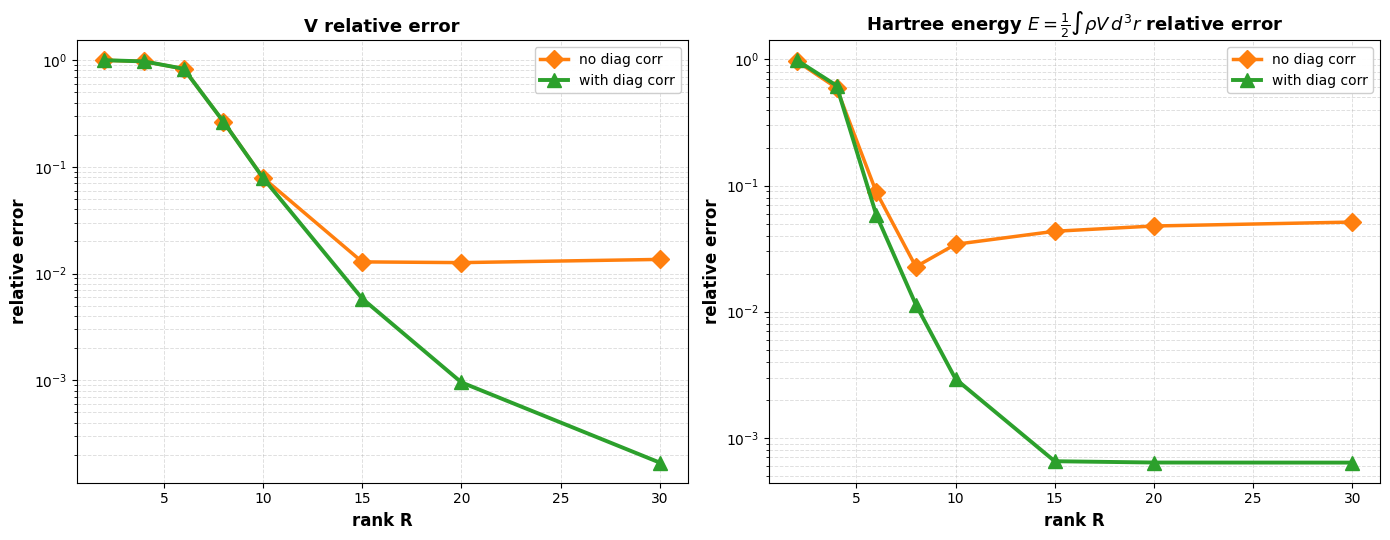

In [7]:
# ===== 各 R に対する V / E 相対誤差 (対角補正あり / なし) =====
x_axis = xyz[0, :, 0, 0]
cell_int_const = 2.38                    # 立方体セル ∫ 1/r d³r / dx²
K_diag_true = cell_int_const / dx

# 解析エネルギー: E = (1/2) ∫ ρ V d³r
E_analytic = 0.5 * np.sum(rho_grid * V_analytic) * dx**3

err_v_no_corr   = {}
err_v_with_corr = {}
err_e_no_corr   = {}
err_e_with_corr = {}

for r, fit in fits.items():
    V_exp = np.zeros_like(rho_grid)
    for w_k, alpha_k in zip(fit.weights, fit.alphas):
        V_exp += w_k * apply_separable_kernel_3d(alpha_k, x_axis, rho_grid)

    V_no   = V_exp * dx**3
    V_corr = (V_exp + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3

    err_v_no_corr[r]   = np.linalg.norm(V_no   - V_analytic) / np.linalg.norm(V_analytic)
    err_v_with_corr[r] = np.linalg.norm(V_corr - V_analytic) / np.linalg.norm(V_analytic)

    E_no   = 0.5 * np.sum(rho_grid * V_no)   * dx**3
    E_corr = 0.5 * np.sum(rho_grid * V_corr) * dx**3
    err_e_no_corr[r]   = abs(E_no   - E_analytic) / abs(E_analytic)
    err_e_with_corr[r] = abs(E_corr - E_analytic) / abs(E_analytic)

# ----- 表 -----
print(f"E_analytic = {E_analytic:.6e}")
print(f"{'R':>4s} | {'1/r L2':>10s} | "
      f"{'V err (no)':>10s} | {'V err (corr)':>12s} | "
      f"{'E err (no)':>10s} | {'E err (corr)':>12s} | {'Σw_k':>8s}")
print("-" * 90)
for r in sorted(fits):
    print(
        f"{r:>4d} | {fits[r].l2_error:>10.3e} | "
        f"{err_v_no_corr[r]:>10.3e} | {err_v_with_corr[r]:>12.3e} | "
        f"{err_e_no_corr[r]:>10.3e} | {err_e_with_corr[r]:>12.3e} | "
        f"{fits[r].weights.sum():>8.3f}"
    )

# ----- 図 -----
ranks_sorted = sorted(fits.keys())
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.semilogy(ranks_sorted, [err_v_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_v_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title('V relative error', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

ax = axes[1]
ax.semilogy(ranks_sorted, [err_e_no_corr[r]   for r in ranks_sorted],
            'D-',  markersize=9, lw=2.5, label='no diag corr',   color='C1')
ax.semilogy(ranks_sorted, [err_e_with_corr[r] for r in ranks_sorted],
            '^-',  markersize=10, lw=2.8, label='with diag corr', color='C2')
ax.set_xlabel('rank R', fontsize=12, fontweight='bold')
ax.set_ylabel('relative error', fontsize=12, fontweight='bold')
ax.set_title(r'Hartree energy $E=\frac{1}{2}\int\rho V\,d^3r$ relative error',
             fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.7)
ax.legend(fontsize=10, loc='best', framealpha=0.95)

plt.tight_layout()
plt.show()


なぜ Rank 15 以降でエネルギーの誤差が打ち止め（プラトー）になるのか？

グリッド分割幅 ($dx$) による離散化誤差（数値積分の限界）が主な原因。

現在の計算では $N=151, L=20$ と設定されているため、グリッドの間隔は $dx \approx 0.132$ となります。エネルギーの計算は配列の単純な和 `np.sum(...) * dx**3`で行われています（リーマン和による区分求積法）。

Rank（指数関数の項数）を増やせば、擬似的な $1/r$ の関数自体はいくらでも真の関数に近づきますが、それを離散的なグリッド上で体積積分する際の「数値積分としての限界」が存在します。この離散化に起因する $O(dx^2)$ レベルの誤差が $10^{-3} \sim 10^{-4}$ のスケールにあるため、これ以上 Rank を上げて近似関数の質を良くしても、全体のエネルギー精度は向上しなくなる

In [ ]:
from src.decomposition.rpca import randomized_rpca
from src.utils.metrics import v_e_errors
from src.utils.cache import load_or_compute

exp_sum_R = 15
fit = fits[exp_sum_R]
x_axis = xyz[0, :, 0, 0]

svd_ranks = [i for i in range(1, 26)]  # 各1DガウシアンのSVDランクを1から25まで試す
errors_v_svd_only = []
errors_e_svd_only = []
errors_v_rpca = []
errors_e_rpca = []

# αごとに1DガウシアンのSVD/RPCA分解を事前計算 (重いのでキャッシュする)
rpca_rank = N // 4
rpca_max_iter = 2000
rpca_tol = 1e-6

def _compute_kernels():
    K_1d_list_local = []
    RPCA_1d_list_local = []
    for alpha_k in fit.alphas:
        K_1D = build_gaussian_kernel_1d(alpha_k, x_axis)
        K_1d_list_local.append(K_1D)

        L_1d, S_1d = randomized_rpca(K_1D, rank=rpca_rank, max_iter=rpca_max_iter, tol=rpca_tol)
        U_L, S_L, Vt_L = np.linalg.svd(L_1d)

        thresh = 1e-2
        sparsity = np.mean(np.abs(S_1d) < thresh)
        print(f"alpha={alpha_k:.4f}  S sparsity: {sparsity:.3f}  (nnz={np.count_nonzero(S_1d)})")

        U_s, S_s, Vt_s = np.linalg.svd(K_1D)

        RPCA_1d_list_local.append({
            'S_1d': S_1d, 'U_L': U_L, 'S_L': S_L, 'Vt_L': Vt_L,
            'U_s': U_s, 'S_s': S_s, 'Vt_s': Vt_s,
        })
    return {"K_1d_list": K_1d_list_local, "RPCA_1d_list": RPCA_1d_list_local}

kernels_cache_params = {
    "N": N,
    "L": L,
    "exp_sum_R": exp_sum_R,
    "alphas": np.asarray(fit.alphas, dtype=np.float64),
    "rpca_rank": rpca_rank,
    "rpca_max_iter": rpca_max_iter,
    "rpca_tol": rpca_tol,
}

kernels_data = load_or_compute(
    namespace="rpca_svd_1d_kernels",
    params=kernels_cache_params,
    compute=_compute_kernels,
)
K_1d_list = kernels_data["K_1d_list"]
RPCA_1d_list = kernels_data["RPCA_1d_list"]

print("1D kernels factored. Calculating 3D potentials...")

for r in svd_ranks:
    V_svd = np.zeros_like(rho_grid)
    V_rpca = np.zeros_like(rho_grid)

    for w_k, k_data in zip(fit.weights, RPCA_1d_list):
        # --- 1) SVD Only (1D) ---
        K_svd_1d = (k_data['U_s'][:, :r] * k_data['S_s'][:r]) @ k_data['Vt_s'][:r, :]

        # 3D畳み込み
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, rho_grid, axis=0)
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, V_s_tmp, axis=1)
        V_s_tmp = apply_1d_kernel_along_axis(K_svd_1d, V_s_tmp, axis=2)
        V_svd += w_k * V_s_tmp

        # --- 2) RPCA (1D L + S) ---
        L_r_1d = (k_data['U_L'][:, :r] * k_data['S_L'][:r]) @ k_data['Vt_L'][:r, :]
        K_rpca_1d = L_r_1d + k_data['S_1d']

        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, rho_grid, axis=0)
        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, V_r_tmp, axis=1)
        V_r_tmp = apply_1d_kernel_along_axis(K_rpca_1d, V_r_tmp, axis=2)
        V_rpca += w_k * V_r_tmp

    # dx**3 & 対角補正
    V_svd_corr = (V_svd + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3
    V_rpca_corr = (V_rpca + (K_diag_true - fit.weights.sum()) * rho_grid) * dx**3

    # 誤差の記録
    err_v_s, err_e_s = v_e_errors(V_svd_corr, V_analytic, rho_grid, dx)
    errors_v_svd_only.append(err_v_s)
    errors_e_svd_only.append(err_e_s)

    err_v_rpca, err_e_rpca = v_e_errors(V_rpca_corr, V_analytic, rho_grid, dx)
    errors_v_rpca.append(err_v_rpca)
    errors_e_rpca.append(err_e_rpca)

# プロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(svd_ranks, errors_v_svd_only, 'o-', lw=2, label='1D SVD only per term')
axes[0].loglog(svd_ranks, errors_v_rpca, 'd-', lw=2, label='1D RPCA (L_svd + S) per term')
axes[0].set_xlabel('rank r (for each 1D Gaussian kernel)', fontsize=12)
axes[0].set_ylabel('relative l2 error of V', fontsize=12)
axes[0].set_title('1D Gaussian Kernels Decomposition (R=15)', fontsize=13)
axes[0].grid(True, which='both', alpha=0.4, ls='--')
axes[0].legend()

axes[1].loglog(svd_ranks, errors_e_svd_only, 'o-', lw=2, label='1D SVD only per term')
axes[1].loglog(svd_ranks, errors_e_rpca, 'd-', lw=2, label='1D RPCA (L_svd + S) per term')
axes[1].set_xlabel('rank r (for each 1D Gaussian kernel)', fontsize=12)
axes[1].set_ylabel('relative error of Hartree E', fontsize=12)
axes[1].set_title('1D Gaussian Kernels Decomposition (R=15)', fontsize=13)
axes[1].grid(True, which='both', alpha=0.4, ls='--')
axes[1].legend()

plt.tight_layout()
plt.show()


計算時間の比較 (3D 指数和近似)

1D の議論を3次元に拡張する。
1つの Gaussian カーネル `K (N×N)` を `ρ (N,N,N)` の各軸に作用させる(`apply_1d_kernel_along_axis` を3回呼ぶ)コストを測る。

- **full**: そのまま N×N の `K` を tensordot で適用。各軸 O(N⁴)。
- **low-rank (順序ミス)**: `K_r = (U_r Σ_r) @ V_rᵀ` を **再構成してから** `tensordot` する。N×N に戻ってしまうので O(N⁴) に逆戻り。
- **low-rank (正しい順序)**: `K_r` を組み立てず、`V_rᵀ` を先にテンソルに作用させて軸の次元を r に落とし、最後に `U_r` で戻す mode-n product。**O(rN³)**。
- **rPCA**: `K ≈ L + S`。`L` は rank-r で正しい順序。`S` は閾値でゼロ化した後、非ゼロ率が 10% 以下なら **MKL SpMM (sparse-dot-mkl) または scipy.sparse @**、そうでなければ dense tensordot。MKL ランタイムが見つからない / sparse_dot_mkl が無い場合は自動的に scipy.sparse の @ にフォールバックします。

`%%timeit -n 100 -r 7` で測定。

In [ ]:
import os
import sys
import glob
from scipy import sparse


def _find_mkl_rt() -> str | None:
    """MKL ランタイムを Linux / Windows / macOS で探索する.

    優先順位:
      1. 環境変数 MKL_RT (明示指定)
      2. CONDA_PREFIX, MKLROOT, sys.prefix, sys.base_prefix の lib/redist
      3. 既知の OS 別インストールパス
    見つからなければ None (= MKL 無し → scipy.sparse fallback)。
    """
    env_path = os.environ.get("MKL_RT")
    if env_path and os.path.exists(env_path):
        return env_path

    prefixes: list[str] = []
    for key in ("CONDA_PREFIX", "MKLROOT"):
        val = os.environ.get(key)
        if val:
            prefixes.append(val)
    prefixes.extend([
        sys.prefix,
        sys.base_prefix,
        # Linux
        "/opt/intel/oneapi/mkl/latest",
        "/opt/intel/mkl",
        "/usr",
        "/usr/local",
        # Windows
        r"C:\Program Files (x86)\Intel\oneAPI\mkl\latest",
        r"C:\Program Files\Intel\oneAPI\mkl\latest",
    ])

    # 各 OS で MKL ランタイムが置かれる相対パスのパターン
    patterns = [
        # Linux
        "lib/libmkl_rt.so*",
        "lib64/libmkl_rt.so*",
        "lib/intel64/libmkl_rt.so*",
        "lib/intel64_lin/libmkl_rt.so*",
        "lib/x86_64-linux-gnu/libmkl_rt.so*",
        # macOS
        "lib/libmkl_rt.dylib",
        # Windows (pip mkl wheel / conda)
        "Library/bin/mkl_rt.*.dll",
        "Library/bin/mkl_rt.dll",
        # Windows (Intel oneAPI standalone)
        "redist/intel64/mkl_rt.*.dll",
        "redist/intel64/mkl_rt.dll",
    ]

    for prefix in prefixes:
        for pattern in patterns:
            for hit in glob.glob(os.path.join(prefix, pattern)):
                if os.path.exists(hit):
                    return hit
    return None


# ---- MKL 検出 (失敗しても止まらない) ----
USE_MKL = False
dot_product_mkl = None  # fallback

mkl_rt = _find_mkl_rt()
if mkl_rt is not None:
    os.environ["MKL_RT"] = mkl_rt
    # Windows 用: DLL 探索パスを追加
    if hasattr(os, "add_dll_directory") and os.name == "nt":
        try:
            os.add_dll_directory(os.path.dirname(mkl_rt))
        except (OSError, FileNotFoundError):
            pass
    try:
        from sparse_dot_mkl import dot_product_mkl as _dpm
        dot_product_mkl = _dpm
        USE_MKL = True
        print(f"[MKL] using {mkl_rt}")
    except ImportError as e:
        print(f"[MKL] sparse_dot_mkl import failed -> scipy.sparse fallback ({e})")
else:
    print("[MKL] runtime not found -> scipy.sparse fallback")


# ---- 計測用パラメータ ----
r_bench = 15            # 上の誤差評価プロットで使用した SVD のランクに合わせる
tau_bench = 1e-2        # 上のRPCAで使った閾値 (thresh) に合わせる
sparse_ratio_threshold = 0.1  # nnz / N^2 <= 10% なら sparse 経路 (MKL or scipy)

# ---- 事前計算されたデータ（上のセルで作成したリスト）を流用 (計測対象外) ----
full_kernels = []
lowrank_data = []
rpca_dense_data = []
rpca_sparse_data = []

sparse_count = 0
dense_count = 0

for i, (alpha_k, w_k) in enumerate(zip(fit.alphas, fit.weights)):
    K_1d = K_1d_list[i]
    k_data = RPCA_1d_list[i]

    # 事前計算済みの SVD から必要なランク分だけ切り出し
    Ur  = k_data['U_s'][:, :r_bench]
    sr  = k_data['S_s'][:r_bench]
    Vtr = k_data['Vt_s'][:r_bench, :]

    # 事前計算済みの RPCA (L+S) から S_1d と L の必要ランク分を切り出し
    UrL  = k_data['U_L'][:, :r_bench]
    srL  = k_data['S_L'][:r_bench]
    VtrL = k_data['Vt_L'][:r_bench, :]

    S_1d = k_data['S_1d']
    S_thr = np.where(np.abs(S_1d) > tau_bench, S_1d, 0.0)
    nnz_ratio = np.count_nonzero(S_thr) / S_thr.size
    if nnz_ratio <= sparse_ratio_threshold:
        S_sp = sparse.csr_matrix(S_thr)
        rpca_sparse_data.append((w_k, UrL, srL, VtrL, S_sp))
        sparse_count += 1
    else:
        rpca_dense_data.append((w_k, UrL, srL, VtrL, S_thr))
        dense_count += 1

    full_kernels.append((w_k, K_1d))
    lowrank_data.append((w_k, Ur, sr, Vtr))

print(f"rpca path: dense={dense_count}, sparse={sparse_count}  (MKL={USE_MKL})")


def apply_full_all(rho):
    out = np.zeros_like(rho)
    for w_k, K in full_kernels:
        tmp = apply_1d_kernel_along_axis(K, rho, axis=0)
        tmp = apply_1d_kernel_along_axis(K, tmp, axis=1)
        tmp = apply_1d_kernel_along_axis(K, tmp, axis=2)
        out += w_k * tmp
    return out

def apply_lowrank_bad_all(rho):
    out = np.zeros_like(rho)
    for w_k, U_r, s_r, Vt_r in lowrank_data:
        K_r = (U_r * s_r) @ Vt_r
        tmp = apply_1d_kernel_along_axis(K_r, rho, axis=0)
        tmp = apply_1d_kernel_along_axis(K_r, tmp, axis=1)
        tmp = apply_1d_kernel_along_axis(K_r, tmp, axis=2)
        out += w_k * tmp
    return out

def apply_lowrank_good_axis(U_r, s_r, Vt_r, rho, axis):
    tmp = np.tensordot(Vt_r, rho, axes=([1], [axis]))
    tmp = np.moveaxis(tmp, 0, axis)
    shape = [1, 1, 1]; shape[axis] = -1
    tmp = tmp * s_r.reshape(shape)
    out = np.tensordot(U_r, tmp, axes=([1], [axis]))
    return np.moveaxis(out, 0, axis)

def apply_lowrank_good_all(rho):
    """従来の sequential な mode-n product"""
    out = np.zeros_like(rho)
    for w_k, U_r, s_r, Vt_r in lowrank_data:
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, rho, axis=0)
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, tmp, axis=1)
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, tmp, axis=2)
        out += w_k * tmp
    return out

def apply_sparse_axis_dense(S_dense, rho, axis):
    tmp = np.tensordot(S_dense, rho, axes=([1], [axis]))
    return np.moveaxis(tmp, 0, axis)


def _apply_sparse_axis_mkl(S_sp, rho, axis):
    rho_m = np.ascontiguousarray(np.moveaxis(rho, axis, 0))
    rest = rho_m.shape[1:]
    out = dot_product_mkl(S_sp, rho_m.reshape(rho_m.shape[0], -1)).reshape(rho_m.shape[0], *rest)
    return np.moveaxis(out, 0, axis)


def _apply_sparse_axis_scipy(S_sp, rho, axis):
    """scipy.sparse CSR を 3D テンソルの指定軸に作用させる (MKL fallback)."""
    rho_m = np.ascontiguousarray(np.moveaxis(rho, axis, 0))
    rest = rho_m.shape[1:]
    out = (S_sp @ rho_m.reshape(rho_m.shape[0], -1)).reshape(rho_m.shape[0], *rest)
    return np.moveaxis(out, 0, axis)


# 実行時に MKL の有無で分岐
apply_sparse_axis_mkl = _apply_sparse_axis_mkl if USE_MKL else _apply_sparse_axis_scipy


def apply_rpca_all(rho):
    out = np.zeros_like(rho)
    for w_k, U_r, s_r, Vt_r, S_dense in rpca_dense_data:
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, rho, axis=0) + apply_sparse_axis_dense(S_dense, rho, axis=0)
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, tmp, axis=1) + apply_sparse_axis_dense(S_dense, tmp, axis=1)
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, tmp, axis=2) + apply_sparse_axis_dense(S_dense, tmp, axis=2)
        out += w_k * tmp
    for w_k, U_r, s_r, Vt_r, S_sp in rpca_sparse_data:
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, rho, axis=0) + apply_sparse_axis_mkl(S_sp, rho, axis=0)
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, tmp, axis=1) + apply_sparse_axis_mkl(S_sp, tmp, axis=1)
        tmp = apply_lowrank_good_axis(U_r, s_r, Vt_r, tmp, axis=2) + apply_sparse_axis_mkl(S_sp, tmp, axis=2)
        out += w_k * tmp
    return out

# ---- 正しさチェック ----
ref = apply_full_all(rho_grid)
err_bad   = np.linalg.norm(apply_lowrank_bad_all(rho_grid) - ref) / np.linalg.norm(ref)
err_good  = np.linalg.norm(apply_lowrank_good_all(rho_grid) - ref) / np.linalg.norm(ref)
err_rpca  = np.linalg.norm(apply_rpca_all(rho_grid) - ref) / np.linalg.norm(ref)

print(f"rel.err  bad={err_bad:.2e}  good={err_good:.2e}  rpca={err_rpca:.2e}")


In [ ]:
%%timeit  -r 7
# (1) full: K (N×N) を3軸に tensordot -> O(3 N^4)
apply_full_all(rho_grid)

369 ms ± 3.56 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit -r 7
# (2) low-rank だが順序ミス: K_r を組み立て直して適用 -> O(N^4) のまま
apply_lowrank_bad_all(rho_grid)

331 ms ± 5.85 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit -r 7
# (3) low-rank で正しい順序: mode-n product -> O(r N^3)
apply_lowrank_good_all(rho_grid)

298 ms ± 6.23 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit -r 7
# (4) rPCA: L is rank-r mode-n product; S uses MKL SpMM or dense tensordot (pre-selected)
apply_rpca_all(rho_grid)

735 ms ± 47.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
